# Notebook 05 - BERT Classification

This notebook trains BERT models to predict which subreddit a post came from.

# Step 1 - Loading the data

In [1]:
import pandas as pd
df = pd.read_csv('../data/reddit_ai_posts_CLEAN.csv')

# Step 2 - Getting the data ready for BERT

First, we encode the subreddit label to be numeric because we cannot use string labels with BERT. Then, we split the dataset into training and testing, using an 80-20 split.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df["subreddit_torch_encoded"] = LabelEncoder().fit_transform(df["subreddit"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["subreddit"], random_state=42)

# Step 3 - Creating the MyDataset class needed for BERT

In [3]:
from torch.utils.data import Dataset
import torch

class MyDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels
  
  def __getitem__(self, idx):
    item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
    item["labels"] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

# Step 4 - Load tokenizers and BERT models

We load two BERT models and their corresponding tokenizers that we will fine-tune to predict the subreddits of reddit posts. We store these in the `models` dict, where the key is the model name and the value is the (loaded model, tokenizer) tuple. I chose to use the `bert-base-uncased` and `distilbert-base-uncased` models for this project.

In [5]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_names = ["bert-base-uncased", "distilbert/distilbert-base-uncased"]
models = {}

for model_name in model_names:
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(df["subreddit_torch_encoded"].unique()))
  models[model_name] =  (model, tokenizer)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13711.83it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

# Step 4 - Creating our datasets

We create our train and test datasets for each BERT model. These datasets are stored in the `datasets`, where the key is the model name and the value is the (train dataset, test dataset) tuple.

In [6]:
def tokenize(data, tokenizer):
  return tokenizer(list(data), padding=True, truncation=True)

datasets = {}

for model_name, (model, tokenizer) in models.items():
  train_dataset = MyDataset(tokenize(train_df["text"], tokenizer), list(train_df["subreddit_torch_encoded"]))
  test_dataset = MyDataset(tokenize(test_df["text"], tokenizer), list(test_df["subreddit_torch_encoded"]))
  datasets[model_name] = (train_dataset, test_dataset)

# Step 5 - Training

We train (fine-tune) each model on our dataset. We add each trained model to the `trainers` dict, where the key is the model name and the value is the trained model.

In [7]:
from transformers import Trainer

trainers = {}

for model_name in models.keys():
  model = models[model_name][0]
  train_dataset = datasets[model_name][0]
  trainer = Trainer(model, train_dataset=train_dataset)
  trainer.train()
  trainers[model_name] = trainer

/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.624178


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.62s/it]
/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]
/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.626293


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]
/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


# Step 6 - Getting the scikit-learn classification report for the models.

In [10]:
from sklearn.metrics import classification_report
import numpy as np

for model_name in models.keys():
  print("Model:", model_name)
  trainer = trainers[model_name]
  test_dataset = datasets[model_name][1]
  out = trainer.predict(test_dataset)
  pred = np.argmax(out.predictions, axis=1)
  print(classification_report(test_dataset.labels, pred))

Model: bert-base-uncased


/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.65      0.66      0.66       117
           1       0.99      0.98      0.99       197
           2       0.63      0.65      0.64       156
           3       0.59      0.57      0.58       116

    accuracy                           0.75       586
   macro avg       0.72      0.72      0.72       586
weighted avg       0.75      0.75      0.75       586

Model: distilbert/distilbert-base-uncased


/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.67      0.70      0.69       117
           1       1.00      0.98      0.99       197
           2       0.64      0.67      0.65       156
           3       0.63      0.59      0.61       116

    accuracy                           0.76       586
   macro avg       0.73      0.73      0.73       586
weighted avg       0.76      0.76      0.76       586



We can see that bert-base-uncased has an accuracy of 0.75 and distilbert-base-uncased has an accuracy of 0.76.

# Step 7 - Confusion matrices

A confusion matrix is a grid where:
- **Rows** = the true subreddit of each post
- **Columns** = what the model predicted
- **Diagonal** = correct predictions (want these high)
- **Off-diagonal** = mistakes (want these low)

We show the two models side by side so you can see exactly where each one struggles.

/opt/homebrew/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


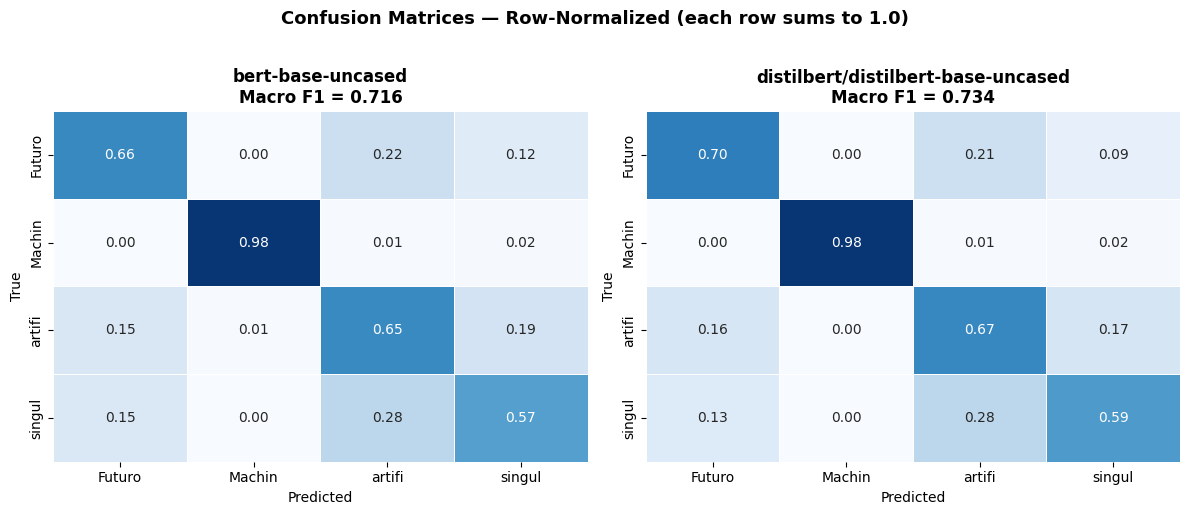

How to read: each row = true class. Values show fraction of that class predicted as each column.
Perfect classifier = 1.0 on every diagonal, 0.0 everywhere else.


In [ ]:
# Note: The code below was written by Claude. I asked it to adapt Varun's correspodning code in the classification notebook to these BERT models.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

# Decode the label order so the matrix axes show the actual subreddit names
le = LabelEncoder().fit(df["subreddit"])
SUB_ORDER = list(range(len(le.classes_)))
short_labels = [name[:6] for name in le.classes_]  # truncate long subreddit names

# Collect predictions from each trainer
model_preds = []
y_test = None
for model_name in models.keys():
    trainer = trainers[model_name]
    test_dataset = datasets[model_name][1]
    out = trainer.predict(test_dataset)
    pred = np.argmax(out.predictions, axis=1)
    model_preds.append((model_name, pred))
    if y_test is None:
        y_test = np.array(test_dataset.labels)

fig, axes = plt.subplots(1, len(model_preds), figsize=(6 * len(model_preds), 5))
if len(model_preds) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=SUB_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, vmin=0, vmax=1,
        linewidths=0.4, cbar=False,
    )
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro F1 = {macro_f1:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

fig.suptitle('Confusion Matrices — Row-Normalized (each row sums to 1.0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('How to read: each row = true class. Values show fraction of that class predicted as each column.')
print('Perfect classifier = 1.0 on every diagonal, 0.0 everywhere else.')

## Step 8 — Per-Class F1 Comparison

The chart shows F1 score per class for all three models side by side. This is the clearest way to see which model wins and where each model struggles.

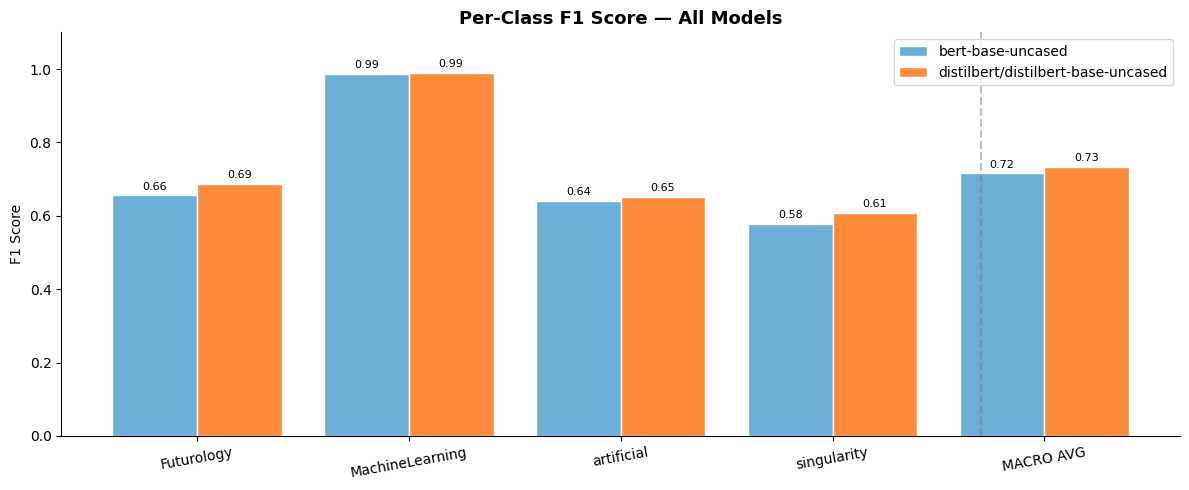


Summary Table:
Model            bert-base-uncased  distilbert/distilbert-base-uncased
Subreddit                                                             
Futurology                   0.655                               0.686
MachineLearning              0.987                               0.990
artificial                   0.642                               0.652
singularity                  0.579                               0.607
MACRO AVG                    0.716                               0.734


In [ ]:
# Note: This code was written by Claude. Similarly as in step 7, I asked Claude to adapt Varun's code in the classification notebook to the BERT models.

# Build model_preds dict from your trainers (reuses y_test from previous cell)
model_preds_dict = {name: pred for name, pred in model_preds}

# Use the actual subreddit names as x-axis labels instead of integer IDs
sub_names = list(le.classes_)

f1_rows = []
for model_name, y_pred in model_preds_dict.items():
    f1_per_class = f1_score(y_test, y_pred, labels=SUB_ORDER, average=None)
    macro        = f1_score(y_test, y_pred, average='macro')
    for sub, f1 in zip(sub_names, f1_per_class):
        f1_rows.append({'Model': model_name, 'Subreddit': sub, 'F1': f1})
    f1_rows.append({'Model': model_name, 'Subreddit': 'MACRO AVG', 'F1': macro})

f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x_labels = sub_names + ['MACRO AVG']
x = np.arange(len(x_labels))
n_models = len(model_preds_dict)
width = 0.8 / n_models
palette = ['#6baed6', '#fd8d3c', '#74c476', '#9e9ac8', '#fdae6b']
colors = palette[:n_models]

for i, (model_name, color) in enumerate(zip(model_preds_dict.keys(), colors)):
    vals = [f1_df[(f1_df.Model == model_name) & (f1_df.Subreddit == s)]['F1'].values[0]
            for s in x_labels]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(x_labels, rotation=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, fontweight='bold')
ax.axvline(x=len(sub_names) - 0.5 + width * n_models / 2, color='gray', linestyle='--', alpha=0.5)
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Summary table
print('\nSummary Table:')
pivot = f1_df.pivot(index='Subreddit', columns='Model', values='F1').reindex(sub_names + ['MACRO AVG'])
print(pivot.round(3).to_string())

# Step 9 - Discussion

First, we can see that BERT models offer a significant improvement over models based on TF-IDF. The best accuracy for a model based on TF-IDF was 67.2%, while both BERT models have at least 75% accuracy. One interesting thing about these BERT models is that they perform extremely well on the MachineLearning subreddit (98% F1 score!), but not as well on other subreddits. We see a similar trend in the models based on TF-IDF, but it is not nearly as pronounced. This could indicate that people in the MachineLearning subreddit use distinct terms that make it easy for models to differentiate posts from that subreddit.